## Retrieval Performance by Topic Category

This notebook analyzes context precision and recall across the 36 health topic categories to identify where the retrieval pipeline performs well vs. struggles.

In [1]:
import os
from pathlib import Path


if Path('evaluation/results').exists():
    pass  
elif Path('../evaluation/results').exists():
    os.chdir('..')
else:
    raise RuntimeError('Run this notebook from the HealthInformer project root')

print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ashhad/HealthInformer


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.makedirs('figures', exist_ok=True)

bedrock = pd.read_csv('evaluation/results/ragas_bedrock.csv')
llama = pd.read_csv('evaluation/results/ragas_llama.csv')

# Average both models per category for retrieval metrics
bedrock['source'] = 'Haiku'
llama['source'] = 'Llama'
combined = pd.concat([bedrock, llama])

retrieval = combined.groupby('category').agg(
    context_precision=('llm_context_precision_with_reference', 'mean'),
    context_recall=('context_recall', 'mean'),
    n=('category', 'count')
).sort_values('context_precision', ascending=True)

print(f'{len(retrieval)} categories, {len(combined)} total questions')
print(retrieval.head())

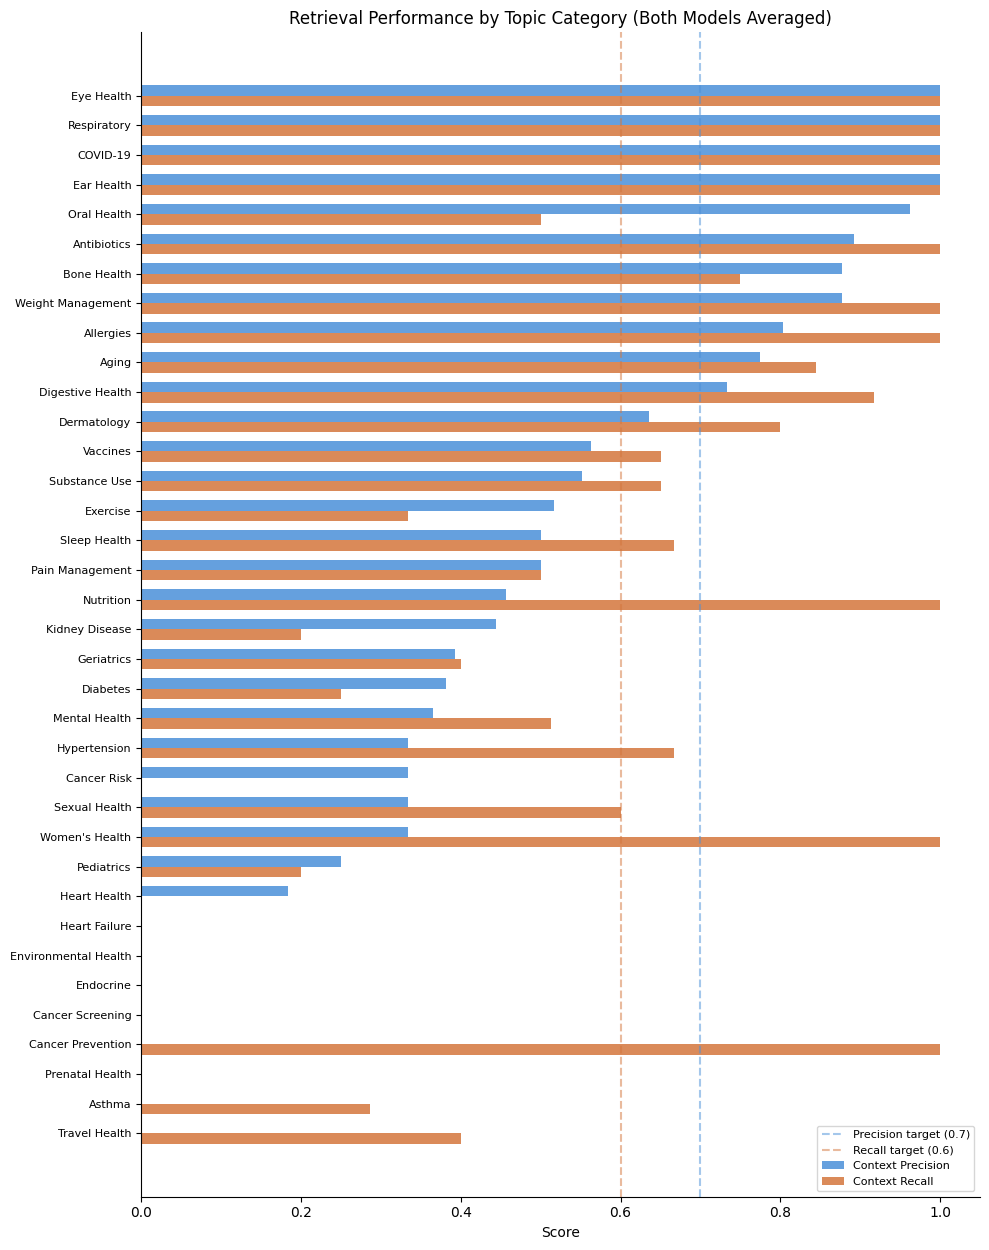

In [3]:
fig, ax = plt.subplots(figsize=(10, max(8, len(retrieval) * 0.35)))

y = np.arange(len(retrieval))
height = 0.35

ax.barh(y + height/2, retrieval['context_precision'], height, 
        label='Context Precision', color='#4A90D9', alpha=0.85)
ax.barh(y - height/2, retrieval['context_recall'], height,
        label='Context Recall', color='#D4763C', alpha=0.85)

# Threshold lines
ax.axvline(x=0.7, color='#4A90D9', linestyle='--', alpha=0.5, label='Precision target (0.7)')
ax.axvline(x=0.6, color='#D4763C', linestyle='--', alpha=0.5, label='Recall target (0.6)')

ax.set_yticks(y)
ax.set_yticklabels(retrieval.index, fontsize=8)
ax.set_xlabel('Score')
ax.set_title('Retrieval Performance by Topic Category (Both Models Averaged)')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/retrieval_by_topic.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### Observations

- Topics with direct clinical terminology in PubMed (e.g., vaccines, respiratory, diabetes) tend to have stronger retrieval scores

- Broader wellness topics (e.g., aging, exercise, nutrition) show weaker retrieval. Possibly the vocabulary gap between layman queries and clinical abstracts is harder for HyDE to bridge in these domains

- Context precision and recall are correlated: when the retriever finds relevant chunks, they also tend to rank well